In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

**Generalisation error in supervised learning decomposes into bias squared, variance, and irreducible error, reflecting a model's ability to approximate the true underlying function while balancing underfitting and overfitting through optimal complexity.**

### Fundamentals of Supervised Learning
Supervised learning assumes an underlying function $f$ mapping features $\mathbf{x}$ to labels $y$, expressed as $y = f(\mathbf{x}) + \epsilon$, where $\epsilon$ denotes irreducible noise. The objective is to estimate a model $\hat{f}$ that approximates $f$ closely, minimising predictive error on unseen data. This requires discarding noise during training, as excessive focus on training specifics leads to poor generalisation.

The process involves selecting from parametric models (e.g., logistic regression) or non-parametric ones (e.g., decision trees), tuning hyperparameters to control flexibility. High flexibility risks capturing noise, while low flexibility fails to model complex relationships.

### Overfitting and Underfitting
**Overfitting** occurs when $\hat{f}$ memorises training noise, yielding low training error but high test error. This arises from excessive model complexity, allowing adaptation to idiosyncrasies rather than the signal.

**Underfitting** results from insufficient complexity, where $\hat{f}$ cannot capture $f$'s structure, leading to high errors on both training and test sets. It reflects a mismatch between model assumptions and data generating process.

These phenomena highlight the need for balance: overfitting sacrifices generalisation for training fit, underfitting sacrifices both. Diagnostic plots, such as learning curves comparing train/test errors, aid identification.

To illustrate, consider generating synthetic data and fitting models of varying complexity:

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

# Generate synthetic non-linear data
np.random.seed(42)
X = np.sort(5 * np.random.rand(200, 1), axis=0)
y_true = np.sin(X).ravel() + 0.1 * np.random.randn(200)  # True function + noise
X_train, X_test, y_train, y_test = train_test_split(
	X, y_true, test_size=0.3, random_state=42
)

# Fit underfitting model (depth=1)
underfit = DecisionTreeRegressor(max_depth=1, random_state=42)
underfit.fit(X_train, y_train)

# Fit overfitting model (depth=12)
overfit = DecisionTreeRegressor(max_depth=12, random_state=42)
overfit.fit(X_train, y_train)

# Generate predictions
X_plot = np.linspace(0, 5, 500).reshape(-1, 1)
y_under_pred = underfit.predict(X_plot)
y_over_pred = overfit.predict(X_plot)

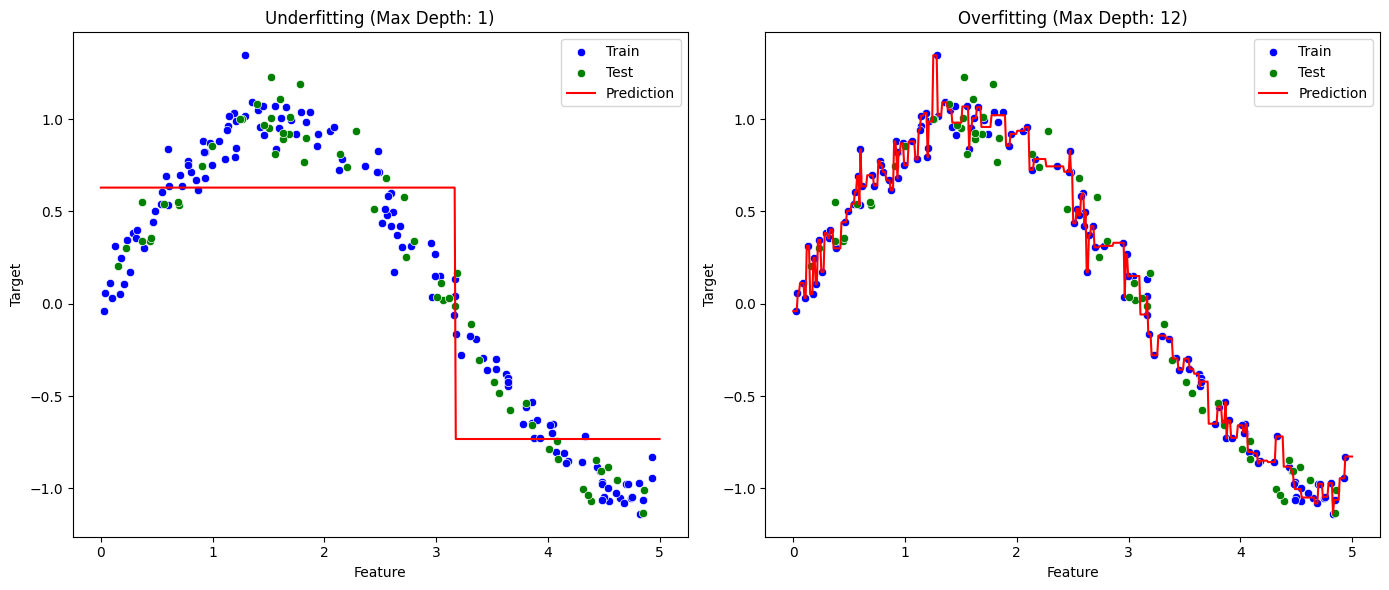

In [3]:
# Set up figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Underfitting
sns.scatterplot(x=X_train.flatten(), y=y_train, color="blue", label="Train", ax=axes[0])
sns.scatterplot(x=X_test.flatten(), y=y_test, color="green", label="Test", ax=axes[0])
sns.lineplot(
	x=X_plot.flatten(), y=y_under_pred, color="red", label="Prediction", ax=axes[0]
)
axes[0].set_title("Underfitting (Max Depth: 1)")
axes[0].set_xlabel("Feature")
axes[0].set_ylabel("Target")

# Right: Overfitting
sns.scatterplot(x=X_train.flatten(), y=y_train, color="blue", label="Train", ax=axes[1])
sns.scatterplot(x=X_test.flatten(), y=y_test, color="green", label="Test", ax=axes[1])
sns.lineplot(
	x=X_plot.flatten(), y=y_over_pred, color="red", label="Prediction", ax=axes[1]
)
axes[1].set_title("Overfitting (Max Depth: 12)")
axes[1].set_xlabel("Feature")
axes[1].set_ylabel("Target")

plt.tight_layout()
plt.show()

This code demonstrates underfitting's smooth but inaccurate fit and overfitting's erratic adherence to points.


### Decomposition of Generalisation Error
Generalisation error quantifies $\hat{f}$'s performance on unseen data, decomposed as:
$$
E\left[(y - \hat{f}(\mathbf{x}))^2\right] = \text{Bias}^2[\hat{f}(\mathbf{x})] + \text{Var}[\hat{f}(\mathbf{x})] + \sigma^2,
$$
where $\sigma^2$ is irreducible error from noise.

**Bias** measures expected deviation: $\text{Bias}[\hat{f}(\mathbf{x})] = E[\hat{f}(\mathbf{x})] - f(\mathbf{x})$. High bias indicates systematic underestimation of $f$'s complexity, causing underfitting.

**Variance** captures sensitivity to training data: $\text{Var}[\hat{f}(\mathbf{x})] = E\left[(\hat{f}(\mathbf{x}) - E[\hat{f}(\mathbf{x})])^2\right]$. High variance implies instability, leading to overfitting.

Irreducible error $\sigma^2 = \text{Var}[\epsilon]$ persists regardless of model, stemming from inherent data variability.

This decomposition explains why minimising total error requires balancing bias and variance, as they often trade off inversely.


### Bias-Variance Tradeoff
Model complexity governs the bias-variance tradeoff: low complexity yields high bias (underfitting), high complexity yields high variance (overfitting). Optimal complexity minimises generalisation error, where bias and variance contribute equally to reducible error.

Graphically, error curves form a U-shape against complexity, with bias decreasing and variance increasing. The nadir represents the best tradeoff.

To visualise:

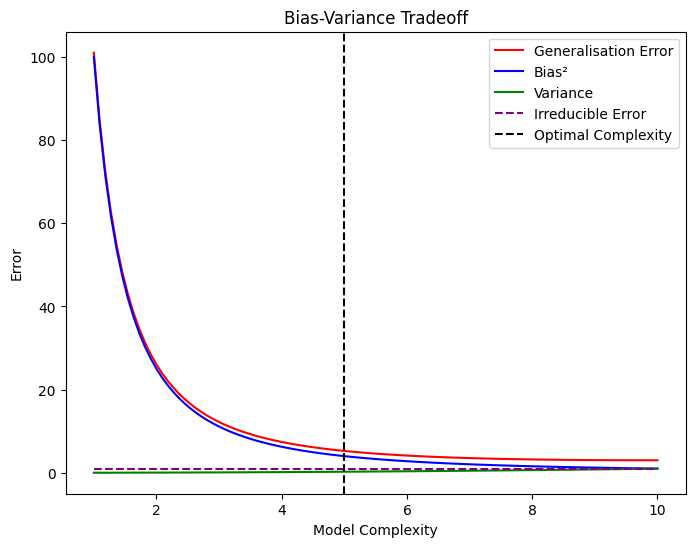

In [4]:
# Simulate bias-variance tradeoff
complexity = np.linspace(1, 10, 100)
bias_sq = (10 / complexity) ** 2
variance = (complexity / 10) ** 2
irreducible = np.full(100, 1.0)
total_error = bias_sq + variance + irreducible

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
sns.lineplot(
	x=complexity, y=total_error, label="Generalisation Error", color="red", ax=ax
)
sns.lineplot(x=complexity, y=bias_sq, label="Bias²", color="blue", ax=ax)
sns.lineplot(x=complexity, y=variance, label="Variance", color="green", ax=ax)
sns.lineplot(
	x=complexity,
	y=irreducible,
	label="Irreducible Error",
	color="purple",
	linestyle="--",
	ax=ax,
)
ax.axvline(x=5, color="black", linestyle="--", label="Optimal Complexity")
ax.set_title("Bias-Variance Tradeoff")
ax.set_xlabel("Model Complexity")
ax.set_ylabel("Error")
ax.legend()
plt.show()

This plot elucidates the tradeoff, emphasising the need for techniques like cross-validation to identify optimal hyperparameters.


### Practical Implications and Mitigation
Achieving low generalisation error demands strategies beyond model selection. Cross-validation estimates error reliably, partitioning data to simulate unseen sets. Regularisation (e.g., tree pruning) curbs variance without inflating bias excessively.

For decision trees, hyperparameters like maximum depth or minimum leaf samples control complexity. Ensembles, such as bagging, average predictions to reduce variance while preserving low bias.

Theoretically, the tradeoff underscores machine learning's no-free-lunch theorem: no universally optimal model exists; performance depends on data alignment with assumptions. Rigorous evaluation on hold-out sets ensures models generalise, prioritising predictive accuracy over training fit.